In [ ]:
# FILE: 05_Symbolic_Discovery.ipynb
# CELL 1: Install PySR and Dependencies

print("--- Installing PySR (This takes ~2-5 minutes) ---")
# 1. Install the python package
%pip install pysr --quiet

# 2. Import and configure (This triggers the Julia download in Colab)
from pysr import PySRRegressor
import os

print("--- PySR Installed. Initializing Julia environment... ---")
# This dummy run forces the backend to compile
try:
    model = PySRRegressor(niterations=5, binary_operators=["+"], verbose=False)
    model.fit([[1]], [1])
    print("[✓] PySR Ready.")
except Exception as e:
    print(f"Initialization Note: {e}")
    print("If this failed, please RESTART THE RUNTIME and run this cell again.")

# --- Standard Imports ---
import pandas as pd
import numpy as np
import geopandas as gpd
from sklearn.preprocessing import StandardScaler
from google.colab import drive

drive.mount('/content/drive', force_remount=True)
%cd "/content/drive/MyDrive/IndiaProject_Colab"

# Load Project Functions
%run 00_Functions_and_Setup.ipynb

--- Installing PySR (This takes ~2-5 minutes) ---
Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
--- PySR Installed. Initializing Julia environment... ---
Initialization Note: `verbose` is not a valid keyword argument for PySRRegressor. Did you mean `verbosity`?
If this failed, please RESTART THE RUNTIME and run this cell again.
Mounted at /content/drive
/content/drive/MyDrive/IndiaProject_Colab
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 55.6 MB/s eta 0:00:00


In [ ]:
# FILE: 05_Symbolic_Discovery.ipynb
# RESTORED CELL: Symbolic Regression on Detrended Anomalies (Top 5 Equations)

import pandas as pd
import numpy as np
import warnings
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from pysr import PySRRegressor

warnings.filterwarnings('ignore')

print("--- Symbolic Regression: Hunting for Mechanisms (Detrended Anomalies) ---")
print("    Goal: Find Yield_Anomaly = f(Soil Moisture, Temperature, Irrigation)")
print("    Method: Removing Linear Trend per district, then pooling Top 50% districts.")

# --- 0. Load Data ---
if 'yld' not in locals():
    print("Loading Master Data...")
    try:
        yld = pd.read_csv("data/processed/icrisat_yield_area_irrig_4crops_long_2000_2017.csv")
    except FileNotFoundError:
        print("CRITICAL: Data file not found.")

# --- Configuration ---
CROPS = ['maize', 'rice', 'sorghum_kharif', 'sorghum_rabi']
TARGET_SHIFT = 0

# PySR Settings
model_params = dict(
    niterations=40,  # Increase for deeper search
    binary_operators=["+", "*", "-", "/"],
    unary_operators=["square"],
    maxsize=10,
    verbosity=0,
    progress=True
)

# --- Helper: Get Pooled DETRENDED Z-Scores (No SIF) ---
def get_pooled_detrended_data(crop_name):
    # 1. Re-assemble Data
    calendar = CROP_CALENDARS[crop_name]
    # Note: Assumes 00_Functions_and_Setup.ipynb has been run for get_climate...
    months = get_month_range(get_middle_month(calendar['planting_start'], calendar['planting_end']),
                             get_middle_month(calendar['harvest_start'], calendar['harvest_end']))

    clim = get_climate_panel_for_months_NO_WEIGHTING(months)

    # 2. Yield & Intensity
    yld_s = yld[yld["crop"] == crop_name].copy()
    yld_s['year'] -= TARGET_SHIFT

    # Filter Top 50% (Core Production Zones)
    avg_area = yld_s.groupby('Dist Code')['total_area_1000ha'].mean().reset_index()
    threshold = avg_area['total_area_1000ha'].quantile(0.5)
    core_districts = avg_area[avg_area['total_area_1000ha'] >= threshold]['Dist Code'].unique()

    yld_core = yld_s[yld_s['Dist Code'].isin(core_districts)].copy()

    # Interpolate Irrig
    yld_core['irrig_area_1000ha'] = yld_core.groupby('Dist Code')['irrig_area_1000ha'].transform(
        lambda x: x.interpolate(method='linear', limit_direction='both')
    )
    yld_core['total_area_temp'] = yld_core['total_area_1000ha'].replace(0, np.nan)
    yld_core['irrigated_pct'] = (yld_core['irrig_area_1000ha'] / yld_core['total_area_temp']).fillna(0).clip(0,1)

    # Merge
    df = pd.merge(clim, yld_core, on=["Dist Code", "year"])

    # Features (NO SIF)
    feat_cols = ['sm_season_mean', 'tmax_season_mean', 'irrigated_pct']
    target_col = YCOL

    df = df.dropna(subset=feat_cols + [target_col])
    if len(df) == 0: return None, None

    # 3. Detrend & Standardize Loop
    pooled_X = []
    pooled_y = []

    for code, g in df.groupby('Dist Code'):
        # Needs enough data to fit a trend
        if len(g) < 15: continue

        # A. Detrend Yield (Remove Technology)
        y_raw = g[target_col].values
        X_time = (g['year'] - g['year'].mean()).values.reshape(-1, 1)

        # Fit Trend
        trend_model = LinearRegression().fit(X_time, y_raw)
        y_trend = trend_model.predict(X_time)

        # Calculate Anomaly (Residual)
        y_anomaly = y_raw - y_trend

        # B. Check Variance
        if np.std(y_anomaly) == 0: continue

        # C. Standardize Inputs and DETRENDED Output
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()

        X_g = g[feat_cols].values

        X_norm = scaler_X.fit_transform(X_g)
        y_norm = scaler_y.fit_transform(y_anomaly.reshape(-1, 1)).flatten()

        pooled_X.append(X_norm)
        pooled_y.append(y_norm)

    if not pooled_X: return None, None
    return np.vstack(pooled_X), np.concatenate(pooled_y)

# --- Main Loop ---
feature_names = ["SM", "Tmax", "Irrig"]

for crop in CROPS:
    print(f"\n==========================================")
    print(f"   Processing: {crop.upper()}")
    print(f"==========================================")

    X, y = get_pooled_detrended_data(crop)
    if X is None:
        print("Insufficient data.")
        continue

    print(f"   Pooled Samples: {X.shape[0]}")

    # Run PySR
    model = PySRRegressor(**model_params)
    model.fit(X, y)

    print(f"\n--- Best Equations for {crop} (No SIF) ---")
    print(f"Mapping: x0={feature_names[0]}, x1={feature_names[1]}, x2={feature_names[2]}")

    # DISPLAY TOP 5 EQUATIONS
    best_eqs = model.equations_.nlargest(5, 'score')
    display(best_eqs[['complexity', 'loss', 'score', 'equation']])

print("\n[✓] Mechanism Discovery Complete.")

--- Symbolic Regression: Hunting for Mechanisms (Detrended Anomalies) ---
    Goal: Find Yield_Anomaly = f(Soil Moisture, Temperature, Irrigation)
    Method: Removing Linear Trend per district, then pooling Top 50% districts.
Loading Master Data...

   Processing: MAIZE
--- Running Climate Aggregation (Smart Season: [5, 6, 7, 8, 9, 10, 11]) ---
   Pooled Samples: 2754

--- Best Equations for maize (No SIF) ---
Mapping: x0=SM, x1=Tmax, x2=Irrig


,complexity,loss,score,equation
1,3,0.974270,0.013033,x0 * 0.16041107
4,7,0.960723,0.007009,x0 * (0.15441668 - (x1 * -0.09393138))
5,8,0.954716,0.006272,(square(0.685444 - x0) * -0.11070659) + 0.1627...
3,6,0.967481,0.004453,(x0 - square(x0)) * 0.09300636
2,5,0.971799,0.001270,(x1 - x0) * -0.096794814



   Processing: RICE
--- Running Climate Aggregation (Smart Season: [6, 7, 8, 9, 10, 11]) ---
   Pooled Samples: 2790

--- Best Equations for rice (No SIF) ---
Mapping: x0=SM, x1=Tmax, x2=Irrig


,complexity,loss,score,equation
1,3,0.951818,0.024691,x0 / 4.5510416
5,10,0.929410,0.005608,(((x0 - x1) - square(x0)) / 8.281376) + 0.1206...
2,5,0.943082,0.004610,(x0 - x1) / 7.4447055
3,7,0.936374,0.003569,(x0 - x1) / (x0 + 7.365505)
4,9,0.934636,0.000928,((x0 - x1) * 0.53104603) / (x0 + 4.5384016)



   Processing: SORGHUM_KHARIF
--- Running Climate Aggregation (Smart Season: [7, 8, 9, 10, 11, 12]) ---
   Pooled Samples: 2772

--- Best Equations for sorghum_kharif (No SIF) ---
Mapping: x0=SM, x1=Tmax, x2=Irrig


,complexity,loss,score,equation
3,6,0.964545,0.012623,(x0 - square(x0)) * 0.09502567
1,3,0.976802,0.011736,x0 * 0.15230829
4,7,0.957603,0.007223,(x0 * (x1 + 1.3362155)) * 0.108007185
5,8,0.952124,0.005739,(square(x0 + -0.59530383) * -0.11905935) - -0....
7,10,0.948660,0.003549,(x2 + ((x0 + 1.0000497) - square(x0))) * 0.126...



   Processing: SORGHUM_RABI
--- Running Climate Aggregation (Smart Season: [11, 12, 1, 2, 3]) ---
    [!] Detected Year-Crossing Season (Start: 11). adjusting logic...
   Pooled Samples: 1890

--- Best Equations for sorghum_rabi (No SIF) ---
Mapping: x0=SM, x1=Tmax, x2=Irrig


,complexity,loss,score,equation
2,5,0.884660,0.033448,(x2 + x0) * 0.26109606
1,3,0.945864,0.027828,x0 * 0.23258333
5,10,0.873904,0.009083,((x0 + x2) - square(x0 * -0.47241452)) * 0.279...
4,9,0.881878,0.001372,((x2 + x0) - (x1 * -0.20355374)) * 0.2758316
3,7,0.884301,0.000203,((x0 * 0.9007026) + x2) * 0.2763821



[✓] Mechanism Discovery Complete.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [ ]:
# FILE: 05_Symbolic_Discovery.ipynb
# NEW CELL: Inspect Maize Equation (Full String)

import pandas as pd
pd.set_option('display.max_colwidth', None) # <--- THE FIX

print("--- Re-inspecting Maize to see full equations ---")

# 1. Get Data for Maize
X, y = get_pooled_detrended_data('maize')

# 2. Run PySR (Quick run to recover the equation)
model = PySRRegressor(**model_params)
model.fit(X, y)

# 3. Get the specific Quadratic Equation
# We look for the one with Complexity ~8 (from your screenshot)
print("\n--- Full Untruncated Equations ---")
best_eqs = model.equations_.nlargest(5, 'score')

# Iterate and print cleanly
for index, row in best_eqs.iterrows():
    print(f"\nComplexity: {row['complexity']}")
    print(f"Loss:       {row['loss']:.6f}")
    print(f"Score:      {row['score']:.6f}")
    print(f"Equation:   {row['equation']}")

--- Re-inspecting Maize to see full equations ---
--- Running Climate Aggregation (Smart Season: [5, 6, 7, 8, 9, 10, 11]) ---

--- Full Untruncated Equations ---

Complexity: 3
Loss:       0.974270
Score:      0.013033
Equation:   x0 * 0.1603344

Complexity: 8
Loss:       0.954716
Score:      0.007855
Equation:   (square(x0 + -0.6867008) * -0.11056142) + 0.16270787

Complexity: 5
Loss:       0.965420
Score:      0.004563
Equation:   x0 / (x0 + 5.674347)

Complexity: 7
Loss:       0.962245
Score:      0.001647
Equation:   ((2.2797537 - x0) * x0) * 0.06803706

Complexity: 10
Loss:       0.952830
Score:      0.000989
Equation:   (((square(x0) + x1) - x0) * -0.09814868) + 0.0981444


In [ ]:
# FILE: 05_Symbolic_Discovery.ipynb
# NEW CELL: Grand Model Comparison (District-Level Refitting)

import pandas as pd
import numpy as np
import geopandas as gpd
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

print("--- Final Model Showdown: Hierarchy vs. Parsimony ---")
print("    Metric: Mean Partial R² (Variance Explained EXCLUDING Trend)")
print("    Method: District-Level Refitting (Local Coefficients)")

# --- 0. Setup ---
if 'yld' not in locals():
    yld = pd.read_csv("data/processed/icrisat_yield_area_irrig_4crops_long_2000_2017.csv")

if 'districts_gdf' not in locals():
    districts_gdf = gpd.read_file("data/processed/districts_joined.gpkg")

# Helper for intensity
def get_cropping_fraction(crop_name):
    crop_data = yld[(yld['crop'] == crop_name) & (yld['yield_kg_per_ha'] > 0)].copy()
    avg_area = crop_data.groupby('Dist Code')['total_area_1000ha'].mean().reset_index()
    avg_area['harvested_ha'] = avg_area['total_area_1000ha'] * 1000

    dist_proj = districts_gdf.to_crs(epsg=6933)
    dist_areas = dist_proj[['Dist Code', 'geometry']].copy()
    dist_areas['district_total_ha'] = dist_proj.geometry.area / 10000

    merged = avg_area.merge(dist_areas, on='Dist Code', how='inner')
    merged['cropping_fraction'] = merged['harvested_ha'] / merged['district_total_ha']
    merged['cropping_fraction'] = merged['cropping_fraction'].clip(upper=1.0)
    return merged[['Dist Code', 'cropping_fraction']]

# --- 1. Load Hierarchical Results ---
# (Adjust paths if necessary)
FILE_LIN   = "results/FINAL_HIERARCHICAL_metrics.parquet"
FILE_QUAD  = "results/FINAL_HIERARCHICAL_QUADRATIC_metrics.parquet"
FILE_INTER = "results/FINAL_HIERARCHICAL_INTERACTION_metrics.parquet"

try:
    df_lin   = pd.read_parquet(FILE_LIN)
    df_quad  = pd.read_parquet(FILE_QUAD)
    df_inter = pd.read_parquet(FILE_INTER)
except FileNotFoundError as e:
    print(f"Error loading files: {e}")

# Filter Shift 0
df_lin = df_lin[df_lin['year_shift'] == 0].copy()
df_quad = df_quad[df_quad['year_shift'] == 0].copy()
df_inter = df_inter[df_inter['year_shift'] == 0].copy()

# Calculate Partials
df_lin['Partial_Linear'] = df_lin['R2_4_Full'] - df_lin['R2_1_Trend']
df_quad['Partial_Quad']  = df_quad['R2_4_Full'] - df_quad['R2_1_Trend']
df_inter['Partial_Inter'] = df_inter['R2_4_Full'] - df_inter['R2_1_Trend']

# --- 2. Calculate SR (Simple) Model Metrics ---
sr_results = []
crops = ['maize', 'rice', 'sorghum_kharif', 'sorghum_rabi']

print("Fitting 'Simple' SR Models per district...")

for crop in crops:
    # Prepare Data
    calendar = CROP_CALENDARS[crop]
    months = get_month_range(get_middle_month(calendar['planting_start'], calendar['planting_end']),
                             get_middle_month(calendar['harvest_start'], calendar['harvest_end']))

    clim = get_climate_panel_for_months_NO_WEIGHTING(months)

    yld_s = yld[yld["crop"] == crop].copy()
    yld_s['year'] -= 0

    # Irrig
    yld_s['irrig_area_1000ha'] = yld_s.groupby('Dist Code')['irrig_area_1000ha'].transform(lambda x: x.interpolate(method='linear', limit_direction='both'))
    yld_s['total_area_temp'] = yld_s['total_area_1000ha'].replace(0, np.nan)
    yld_s['irrigated_pct'] = (yld_s['irrig_area_1000ha'] / yld_s['total_area_temp']).fillna(0).clip(0,1)

    df = pd.merge(clim, yld_s, on=["Dist Code", "year"]).dropna()

    for code, g in df.groupby('Dist Code'):
        if len(g) < 15: continue

        y = g[YCOL].values
        t = (g['year'] - g['year'].mean()).values.reshape(-1, 1)

        # Baseline Trend
        r2_trend = LinearRegression().fit(t, y).score(t, y)

        # --- DEFINING THE SIMPLE MODELS (Based on PySR) ---
        if crop == 'maize':
            # Model: Quadratic SM (Trend + SM + SM^2)
            sm = g['sm_season_mean'].values
            sm_sq = (sm - sm.mean())**2
            X = np.column_stack([t, sm, sm_sq])

        elif crop == 'rice':
            # Model: Soil Moisture Only (Trend + SM)
            # (PySR detrended analysis favored SM over Irrig for anomalies)
            sm = g['sm_season_mean'].values
            X = np.column_stack([t, sm])

        elif crop == 'sorghum_kharif':
            # Model: Interaction (Trend + SM + T + SM*T)
            # We include main effects + interaction to allow the district to tune the sensitivity
            sm = g['sm_season_mean'].values
            temp = g['tmax_season_mean'].values
            inter = (sm - sm.mean()) * (temp - temp.mean())
            X = np.column_stack([t, sm, temp, inter])

        elif crop == 'sorghum_rabi':
            # Model: Additive Water (Trend + SM + Irrig)
            sm = g['sm_season_mean'].values
            irrig = g['irrigated_pct'].values
            X = np.column_stack([t, sm, irrig])

        r2_full = LinearRegression().fit(X, y).score(X, y)
        sr_results.append({'Dist Code': code, 'crop': crop, 'Partial_SR': r2_full - r2_trend})

df_sr = pd.DataFrame(sr_results)

# --- 3. Merge ---
# Inner join to ensure exact sample match
merged = pd.merge(df_lin[['Dist Code', 'crop', 'Partial_Linear']],
                  df_quad[['Dist Code', 'crop', 'Partial_Quad']],
                  on=['Dist Code', 'crop'], how='inner')
merged = pd.merge(merged, df_inter[['Dist Code', 'crop', 'Partial_Inter']], on=['Dist Code', 'crop'], how='inner')
merged = pd.merge(merged, df_sr[['Dist Code', 'crop', 'Partial_SR']], on=['Dist Code', 'crop'], how='inner')

# --- 4. Filtering (Top 50%) ---
cf_list = []
for crop in crops:
    cf = get_cropping_fraction(crop)
    cf['crop'] = crop
    cf_list.append(cf)
cf_all = pd.concat(cf_list)

final_df = pd.merge(merged, cf_all, on=['Dist Code', 'crop'], how='inner')
crop_thresholds = cf_all.groupby('crop')['cropping_fraction'].quantile(0.5).rename('cf_threshold').reset_index()
final_df = final_df.merge(crop_thresholds, on='crop')

top_districts = final_df[final_df['cropping_fraction'] >= final_df['cf_threshold']].drop(columns='cf_threshold').reset_index(drop=True)

# --- 5. Display ---
def make_pretty(df):
    return df.style.background_gradient(cmap='Greens', axis=1).format("{:.3f}")

print("\n=== COMPARISON: Mean Partial R² (Top 50% Districts) ===")
print("    Col 1-3: Hierarchical Models (Kitchen Sink)")
print("    Col 4:   Symbolic Models (Parsimonious)")

table = top_districts.groupby('crop')[['Partial_Linear', 'Partial_Quad', 'Partial_Inter', 'Partial_SR']].mean()
table.columns = ['1. Linear', '2. +Quadratic', '3. +Interaction', '4. SR (Simple)']
display(make_pretty(table))

--- Final Model Showdown: Hierarchy vs. Parsimony ---
    Metric: Mean Partial R² (Variance Explained EXCLUDING Trend)
    Method: District-Level Refitting (Local Coefficients)
Fitting 'Simple' SR Models per district...
--- Running Climate Aggregation (Smart Season: [5, 6, 7, 8, 9, 10, 11]) ---
--- Running Climate Aggregation (Smart Season: [6, 7, 8, 9, 10, 11]) ---
--- Running Climate Aggregation (Smart Season: [7, 8, 9, 10, 11, 12]) ---
--- Running Climate Aggregation (Smart Season: [11, 12, 1, 2, 3]) ---
    [!] Detected Year-Crossing Season (Start: 11). adjusting logic...

=== COMPARISON: Mean Partial R² (Top 50% Districts) ===
    Col 1-3: Hierarchical Models (Kitchen Sink)
    Col 4:   Symbolic Models (Parsimonious)


,1. Linear,2. +Quadratic,3. +Interaction,4. SR (Simple)
crop,,,,
maize,0.261,0.347,0.381,0.158
rice,0.234,0.295,0.329,0.105
sorghum_kharif,0.260,0.387,0.429,0.251
sorghum_rabi,0.411,0.504,0.526,0.276


--- Mapping the Gap: Interaction Model vs. Simple SR Model ---
    Metric: Partial_Inter - Partial_SR
    Interpretation: Darker colors mean the simple equation failed and complexity was required.


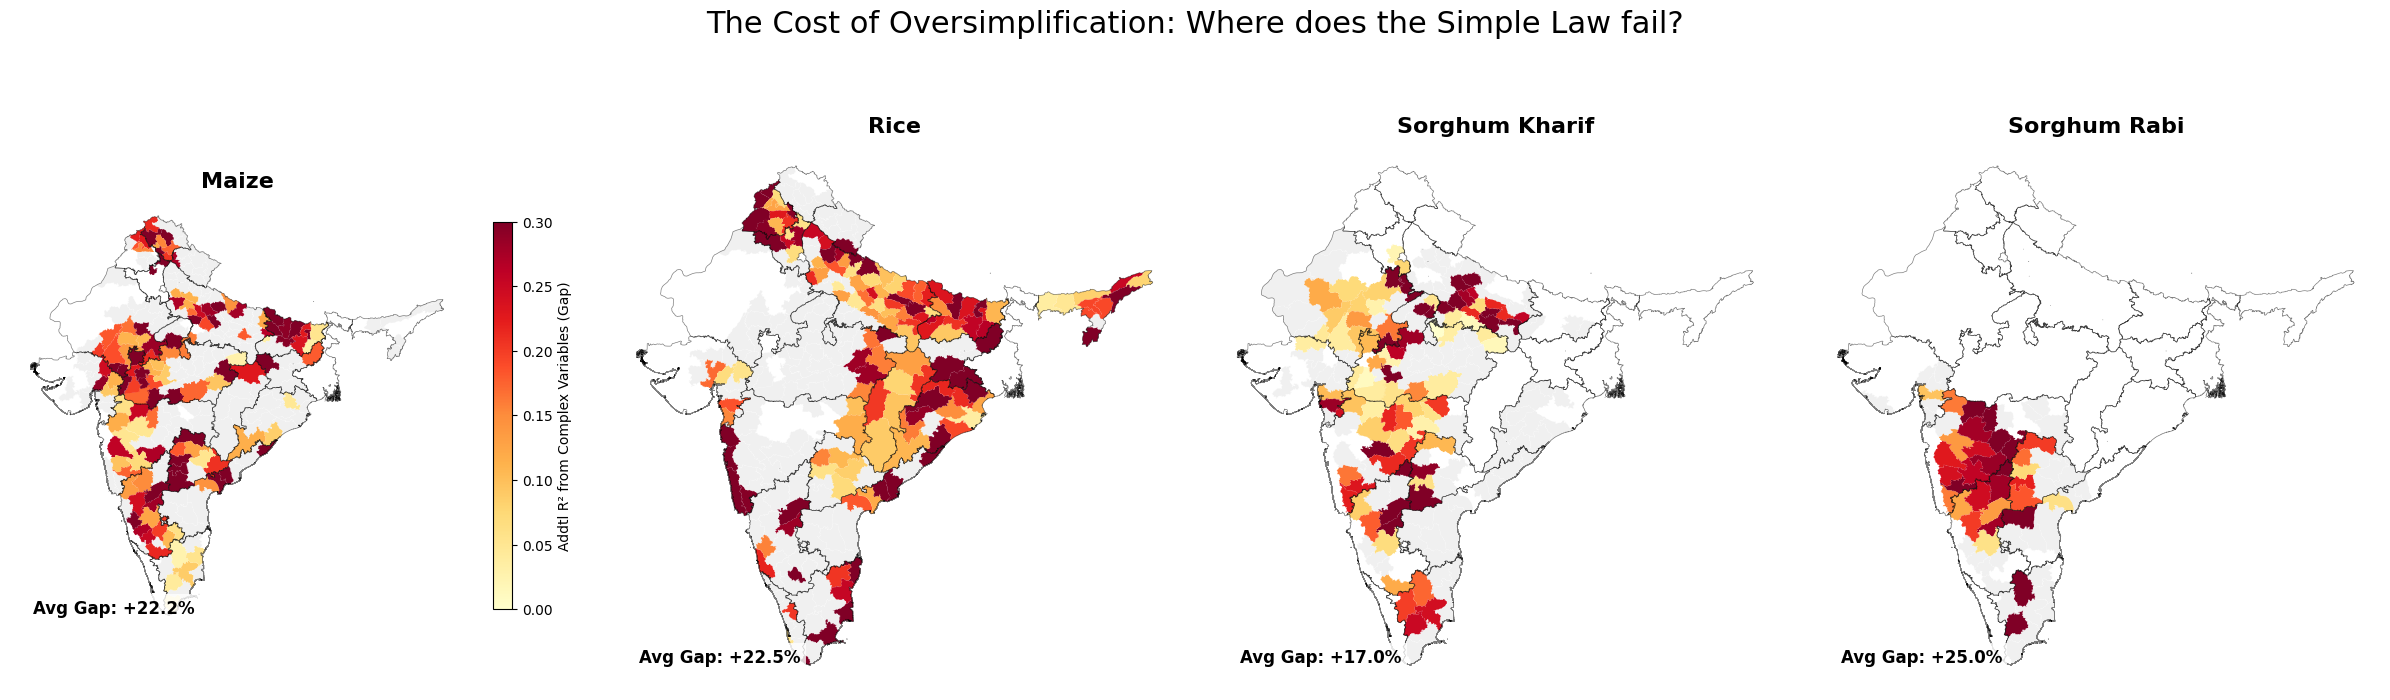

In [ ]:
# FILE: 05_Symbolic_Discovery.ipynb
# NEW CELL: Mapping the "Value of Complexity" (Complex vs SR Gap)

import matplotlib.pyplot as plt

print("--- Mapping the Gap: Interaction Model vs. Simple SR Model ---")
print("    Metric: Partial_Inter - Partial_SR")
print("    Interpretation: Darker colors mean the simple equation failed and complexity was required.")

# 1. Calculate the Gap
# How much MORE variance does the Kitchen Sink explain compared to the Simple Law?
final_df['Complexity_Gap'] = final_df['Partial_Inter'] - final_df['Partial_SR']

# 2. Setup Figure
fig, axes = plt.subplots(1, 4, figsize=(24, 8))
crops =['maize', 'rice', 'sorghum_kharif', 'sorghum_rabi']

# Load Boundaries if missing
if 'state_boundaries_gdf' not in locals():
    state_boundaries_gdf = districts_gdf.dissolve(by='state_shp').reset_index()

for i, crop in enumerate(crops):
    ax = axes[i]

    # A. Filter data
    data = final_df[final_df['crop'] == crop].copy()

    # B. Merge with Geometry
    geo_data = districts_gdf.merge(data, on='Dist Code', how='inner')

    # C. Apply Top 50% Filter
    threshold = cf_all[cf_all['crop'] == crop]['cropping_fraction'].quantile(0.5)

    top_50 = geo_data[geo_data['cropping_fraction'] >= threshold]
    bottom_50 = geo_data[geo_data['cropping_fraction'] < threshold]

    # D. Plot Background (Excluded)
    if not bottom_50.empty:
        bottom_50.plot(ax=ax, color='#f0f0f0', edgecolor='white', linewidth=0.1)

    # E. Plot Foreground (The Gap)
    # Using a 'Purples' or 'YlOrRd' colormap. Darker = Higher Gap
    if not top_50.empty:
        top_50.plot(
            column='Complexity_Gap',
            ax=ax,
            cmap='YlOrRd',  # Yellow (Small Gap) to Red (Large Gap)
            vmin=0, vmax=0.30, # Cap at 30% difference for visualization
            legend=(i==0),
            legend_kwds={'label': 'Addtl R² from Complex Variables (Gap)', 'shrink': 0.6}
        )

    # F. Styling
    state_boundaries_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.5, alpha=0.5)
    ax.set_title(f"{crop.replace('_', ' ').title()}", fontsize=16, fontweight='bold')
    ax.set_axis_off()

    # G. Add Stats
    avg_gap = top_50['Complexity_Gap'].mean()
    ax.text(0.05, 0.05, f"Avg Gap: +{avg_gap*100:.1f}%",
            transform=ax.transAxes, fontsize=12, fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.suptitle("The Cost of Oversimplification: Where does the Simple Law fail?", fontsize=22, y=0.98)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

#OLD ANALYSIS

In [ ]:
# FILE: 05_Symbolic_Discovery.ipynb
# CELL 2: Data Loading & Setup for AICc Test

import pandas as pd
import numpy as np
import warnings
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

print("--- Initializing AICc Model Comparison ---")

# 1. Load Master Data
if 'yld' not in locals():
    print(f"Loading Master Yield Data...")
    try:
        yld = pd.read_csv("data/processed/icrisat_yield_area_irrig_4crops_long_2000_2017.csv")
    except FileNotFoundError:
        print("CRITICAL: Data file not found.")

# 2. Define AICc Function
def calculate_aicc(n, k, rss):
    """
    Computes AICc (Corrected Akaike Information Criterion).
    Penalizes complexity (k) heavily when sample size (n) is small.
    """
    if n <= k + 1: return np.inf # Prevent division by zero

    likelihood = n * np.log(rss / n)
    penalty = 2 * k
    correction = (2 * k * (k + 1)) / (n - k - 1)

    return likelihood + penalty + correction

print("[✓] Data Loaded. AICc function defined.")

--- Initializing AICc Model Comparison ---
Loading Master Yield Data...
[✓] Data Loaded. AICc function defined.


--- Running AICc Comparison on Core Production Zones ---
    Constraint: Analyzing only Top 50% Cropping Intensity Districts
    Goal: Does the Complex Model justify its extra parameters?
Processing maize...
--- Running Climate Aggregation (Smart Season: [5, 6, 7, 8, 9, 10, 11]) ---
--- Generating CROP-WEIGHTED SIF panel (Smart Season) for 'maize' ---
Processing rice...
--- Running Climate Aggregation (Smart Season: [6, 7, 8, 9, 10, 11]) ---
--- Generating CROP-WEIGHTED SIF panel (Smart Season) for 'rice' ---
Processing sorghum_kharif...
--- Running Climate Aggregation (Smart Season: [7, 8, 9, 10, 11, 12]) ---
--- Generating CROP-WEIGHTED SIF panel (Smart Season) for 'sorghum_kharif' ---
Processing sorghum_rabi...
--- Running Climate Aggregation (Smart Season: [11, 12, 1, 2, 3]) ---
    [!] Detected Year-Crossing Season (Start: 11). adjusting logic...
--- Generating CROP-WEIGHTED SIF panel (Smart Season) for 'sorghum_rabi' ---

--- WINNER BY AICc (Top 50% Districts) ---


Winner,Complex (Ours),Simple (PySR),Total,Simple_Win_Pct
crop,,,,
maize,6,140,146,95.9
rice,3,138,141,97.9
sorghum_kharif,2,141,143,98.6
sorghum_rabi,0,64,64,100.0


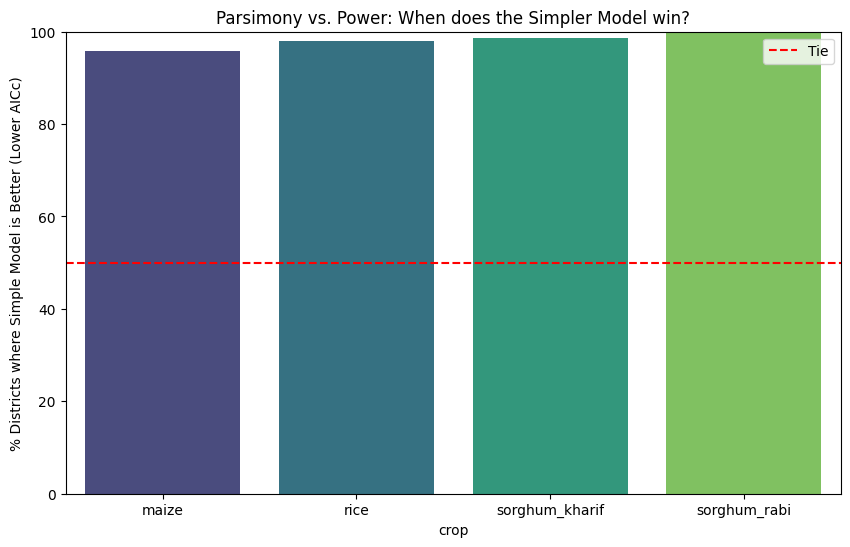

In [ ]:
# FILE: 05_Symbolic_Discovery.ipynb
# CELL 3: AICc Comparison (Top 50% Intensity Districts)

import matplotlib.pyplot as plt
import seaborn as sns

print("--- Running AICc Comparison on Core Production Zones ---")
print("    Constraint: Analyzing only Top 50% Cropping Intensity Districts")
print("    Goal: Does the Complex Model justify its extra parameters?")

results_aic = []
crops = ['maize', 'rice', 'sorghum_kharif', 'sorghum_rabi']
target_shift = 0

for crop in crops:
    print(f"Processing {crop}...")

    # 1. Re-assemble Panel
    calendar = CROP_CALENDARS[crop]
    months = get_month_range(get_middle_month(calendar['planting_start'], calendar['planting_end']),
                             get_middle_month(calendar['harvest_start'], calendar['harvest_end']))

    clim = get_climate_panel_for_months_NO_WEIGHTING(months)
    sif = get_sif_panel_for_months(crop, months)

    yld_s = yld[yld["crop"] == crop].copy()
    yld_s['year'] -= target_shift

    # 2. Identify TOP 50% DISTRICTS (The Filter)
    avg_area = yld_s.groupby('Dist Code')['total_area_1000ha'].mean()
    threshold = avg_area.quantile(0.5)
    core_districts = avg_area[avg_area >= threshold].index

    # Filter Yield Data immediately
    yld_s = yld_s[yld_s['Dist Code'].isin(core_districts)].copy()

    # Interpolate Irrig
    yld_s['irrig_area_1000ha'] = yld_s.groupby('Dist Code')['irrig_area_1000ha'].transform(lambda x: x.interpolate(method='linear', limit_direction='both'))
    yld_s['total_area_temp'] = yld_s['total_area_1000ha'].replace(0, np.nan)
    yld_s['irrigated_pct'] = (yld_s['irrig_area_1000ha'] / yld_s['total_area_temp']).fillna(0).clip(0,1)

    # Merge
    df = pd.merge(clim, sif, on=["Dist Code", "year"])
    df = pd.merge(df, yld_s, on=["Dist Code", "year"]).dropna()

    # 3. Fit Models per District
    for code, g in df.groupby('Dist Code'):
        n = len(g)
        if n < 15: continue

        y = g[YCOL].values
        t = (g['year'] - g['year'].mean()).values.reshape(-1, 1)

        # ---------------------------------------------------------
        # MODEL A: THE COMPLEX (Full Interaction + SIF + Irrig)
        # Params: Intercept(1) + Trend(1) + SM(1) + T(1) + Irrig(1) + SIF(1) + SM2(1) + T2(1) + Inter(1) = 9
        # ---------------------------------------------------------
        k_complex = 9

        X_lin = g[['sm_season_mean', 'tmax_season_mean']].values
        X_irrig = g[['irrigated_pct']].values
        X_sif = g[['csif_season_mean']].values

        # Feature Engineering (Center & Square)
        X_lin_cen = X_lin - X_lin.mean(axis=0)
        X_sq = X_lin_cen ** 2
        X_inter = (X_lin_cen[:,0] * X_lin_cen[:,1]).reshape(-1,1)

        # Combine
        X_complex_raw = np.hstack([t, X_lin, X_sq, X_inter, X_irrig, X_sif])
        # Standardize for numerical stability (doesn't affect R2/AICc fit, just solving)
        X_complex = StandardScaler().fit_transform(X_complex_raw)

        # Fit & Calc Error
        mdl_A = LinearRegression().fit(X_complex, y)
        rss_A = np.sum((y - mdl_A.predict(X_complex)) ** 2)
        aicc_A = calculate_aicc(n, k_complex, rss_A)

        # ---------------------------------------------------------
        # MODEL B: THE PySR SIMPLE (Crop Specific mechanisms)
        # ---------------------------------------------------------

        if crop == 'maize':
            # PySR: Quadratic SM
            # Terms: Intercept, Trend, SM, SM^2 (k=4)
            sm = g['sm_season_mean'].values
            sm_sq = (sm - sm.mean())**2
            X_simple = np.column_stack([t, sm, sm_sq])
            k_simple = 4

        elif crop == 'rice':
            # PySR: Irrigation Only
            # Terms: Intercept, Trend, Irrig (k=3)
            irrig = g['irrigated_pct'].values
            X_simple = np.column_stack([t, irrig])
            k_simple = 3

        elif crop == 'sorghum_kharif':
            # PySR: Interaction Only (SM * T)
            # Terms: Intercept, Trend, SM, T, SM*T (k=5) - Giving it standard interaction form
            sm = g['sm_season_mean'].values
            temp = g['tmax_season_mean'].values
            inter = (sm - sm.mean()) * (temp - temp.mean())
            X_simple = np.column_stack([t, sm, temp, inter])
            k_simple = 5

        elif crop == 'sorghum_rabi':
            # PySR: SM + Irrig
            # Terms: Intercept, Trend, SM, Irrig (k=4)
            sm = g['sm_season_mean'].values
            irrig = g['irrigated_pct'].values
            X_simple = np.column_stack([t, sm, irrig])
            k_simple = 4

        # Fit & Calc Error
        mdl_B = LinearRegression().fit(X_simple, y)
        rss_B = np.sum((y - mdl_B.predict(X_simple)) ** 2)
        aicc_B = calculate_aicc(n, k_simple, rss_B)

        results_aic.append({
            'Dist Code': code,
            'crop': crop,
            'AICc_Complex': aicc_A,
            'AICc_Simple': aicc_B,
            'Winner': 'Simple (PySR)' if aicc_B < aicc_A else 'Complex (Ours)'
        })

# --- 4. Analyze Results ---
aic_df = pd.DataFrame(results_aic)

# Summary Table
print("\n--- WINNER BY AICc (Top 50% Districts) ---")
summary = aic_df.groupby(['crop', 'Winner']).size().unstack(fill_value=0)
summary['Total'] = summary.sum(axis=1)
summary['Simple_Win_Pct'] = (summary['Simple (PySR)'] / summary['Total']) * 100
display(summary.round(1))

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=summary.reset_index(), x='crop', y='Simple_Win_Pct', palette='viridis')
plt.axhline(50, linestyle='--', color='red', label='Tie')
plt.title("Parsimony vs. Power: When does the Simpler Model win?")
plt.ylabel("% Districts where Simple Model is Better (Lower AICc)")
plt.ylim(0, 100)
plt.legend()
plt.show()

--- R² Showdown: Does Simplicity cost us Accuracy? ---
--- Running Climate Aggregation (Smart Season: [5, 6, 7, 8, 9, 10, 11]) ---
--- Generating CROP-WEIGHTED SIF panel (Smart Season) for 'maize' ---
--- Running Climate Aggregation (Smart Season: [6, 7, 8, 9, 10, 11]) ---
--- Generating CROP-WEIGHTED SIF panel (Smart Season) for 'rice' ---
--- Running Climate Aggregation (Smart Season: [7, 8, 9, 10, 11, 12]) ---
--- Generating CROP-WEIGHTED SIF panel (Smart Season) for 'sorghum_kharif' ---
--- Running Climate Aggregation (Smart Season: [11, 12, 1, 2, 3]) ---
    [!] Detected Year-Crossing Season (Start: 11). adjusting logic...
--- Generating CROP-WEIGHTED SIF panel (Smart Season) for 'sorghum_rabi' ---


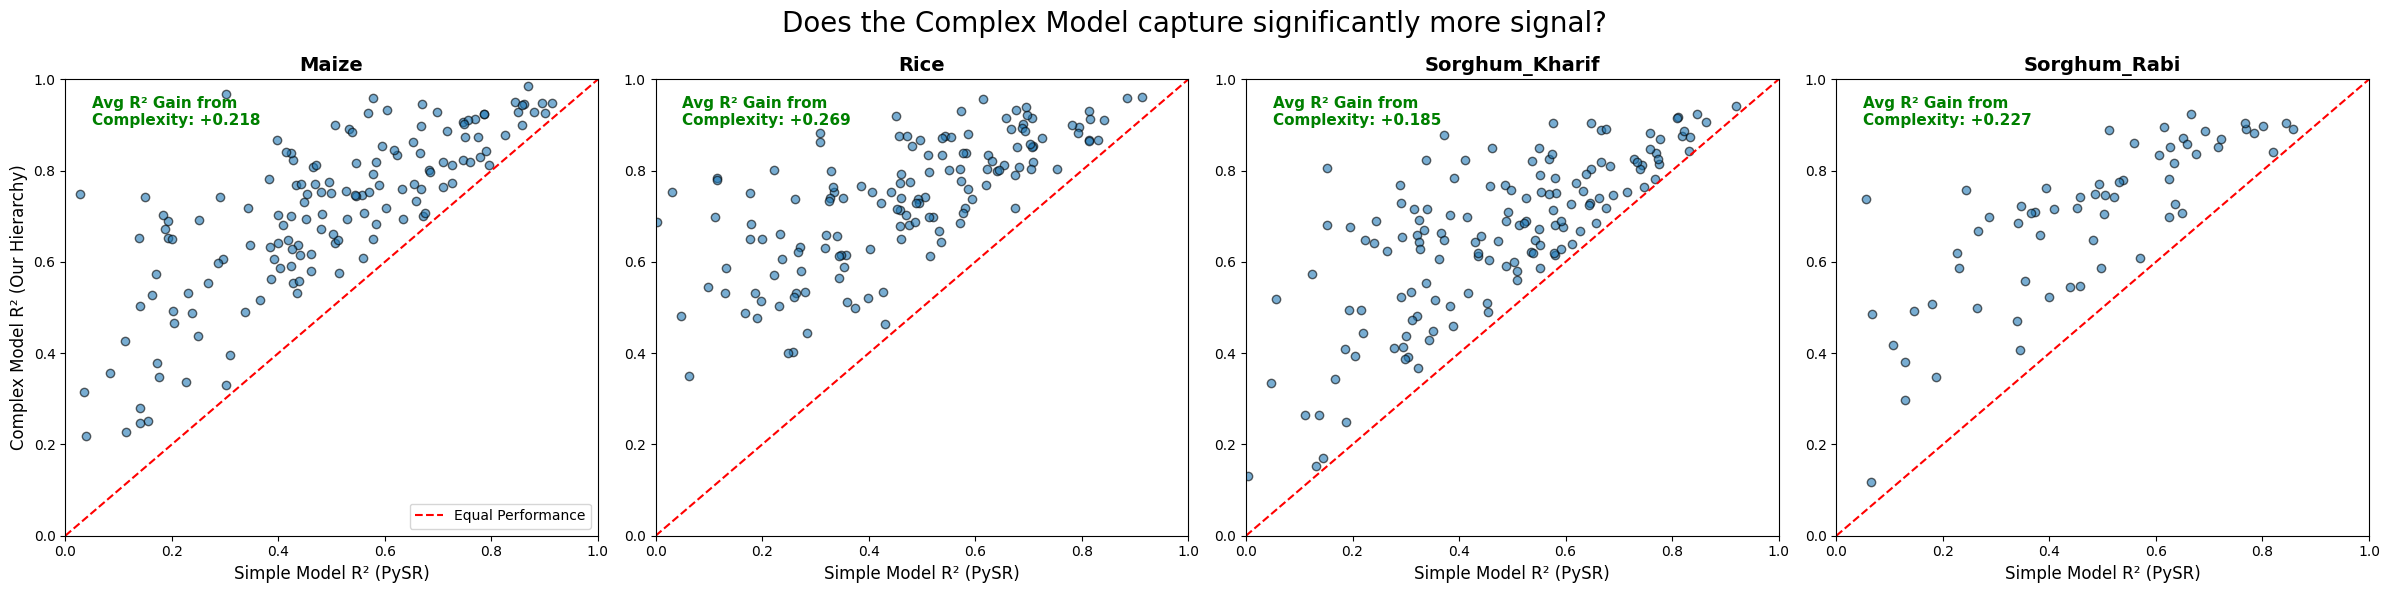

,R2_Simple,R2_Complex,Gain
crop,,,
maize,0.491,0.710,0.218
rice,0.466,0.736,0.269
sorghum_kharif,0.478,0.663,0.185
sorghum_rabi,0.470,0.696,0.227


In [ ]:
# FILE: 05_Symbolic_Discovery.ipynb
# NEW CELL: R2 Comparison (Complex vs. Simple)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

print("--- R² Showdown: Does Simplicity cost us Accuracy? ---")

# --- 1. Load Data (If needed) ---
if 'yld' not in locals():
    yld = pd.read_csv("data/processed/icrisat_yield_area_irrig_4crops_long_2000_2017.csv")

results_r2 = []
crops = ['maize', 'rice', 'sorghum_kharif', 'sorghum_rabi']
target_shift = 0

for crop in crops:
    # Re-assemble Panel
    calendar = CROP_CALENDARS[crop]
    months = get_month_range(get_middle_month(calendar['planting_start'], calendar['planting_end']),
                             get_middle_month(calendar['harvest_start'], calendar['harvest_end']))

    clim = get_climate_panel_for_months_NO_WEIGHTING(months)
    sif = get_sif_panel_for_months(crop, months)

    yld_s = yld[yld["crop"] == crop].copy()
    yld_s['year'] -= target_shift

    # Filter Top 50%
    avg_area = yld_s.groupby('Dist Code')['total_area_1000ha'].mean()
    threshold = avg_area.quantile(0.5)
    core_districts = avg_area[avg_area >= threshold].index
    yld_s = yld_s[yld_s['Dist Code'].isin(core_districts)].copy()

    # Interpolate Irrig
    yld_s['irrig_area_1000ha'] = yld_s.groupby('Dist Code')['irrig_area_1000ha'].transform(lambda x: x.interpolate(method='linear', limit_direction='both'))
    yld_s['total_area_temp'] = yld_s['total_area_1000ha'].replace(0, np.nan)
    yld_s['irrigated_pct'] = (yld_s['irrig_area_1000ha'] / yld_s['total_area_temp']).fillna(0).clip(0,1)

    df = pd.merge(clim, sif, on=["Dist Code", "year"])
    df = pd.merge(df, yld_s, on=["Dist Code", "year"]).dropna()

    for code, g in df.groupby('Dist Code'):
        n = len(g)
        if n < 15: continue

        y = g[YCOL].values
        t = (g['year'] - g['year'].mean()).values.reshape(-1, 1)

        # --- MODEL A: COMPLEX (k=9) ---
        X_lin = g[['sm_season_mean', 'tmax_season_mean']].values
        X_irrig = g[['irrigated_pct']].values
        X_sif = g[['csif_season_mean']].values
        X_lin_cen = X_lin - X_lin.mean(axis=0)
        X_sq = X_lin_cen ** 2
        X_inter = (X_lin_cen[:,0] * X_lin_cen[:,1]).reshape(-1,1)

        X_complex = np.hstack([t, X_lin, X_sq, X_inter, X_irrig, X_sif])
        X_complex = StandardScaler().fit_transform(X_complex)

        r2_complex = LinearRegression().fit(X_complex, y).score(X_complex, y)

        # --- MODEL B: SIMPLE (PySR Driven) ---
        if crop == 'maize':
            sm = g['sm_season_mean'].values
            sm_sq = (sm - sm.mean())**2
            X_simple = np.column_stack([t, sm, sm_sq])

        elif crop == 'rice':
            irrig = g['irrigated_pct'].values
            X_simple = np.column_stack([t, irrig])

        elif crop == 'sorghum_kharif':
            sm = g['sm_season_mean'].values
            temp = g['tmax_season_mean'].values
            inter = (sm - sm.mean()) * (temp - temp.mean())
            X_simple = np.column_stack([t, sm, temp, inter])

        elif crop == 'sorghum_rabi':
            sm = g['sm_season_mean'].values
            irrig = g['irrigated_pct'].values
            X_simple = np.column_stack([t, sm, irrig])

        r2_simple = LinearRegression().fit(X_simple, y).score(X_simple, y)

        results_r2.append({
            'crop': crop,
            'R2_Complex': r2_complex,
            'R2_Simple': r2_simple
        })

# --- Visualization ---
df_r2 = pd.DataFrame(results_r2)

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for i, crop in enumerate(crops):
    ax = axes[i]
    data = df_r2[df_r2['crop'] == crop]

    # Scatter
    ax.scatter(data['R2_Simple'], data['R2_Complex'], alpha=0.6, c='#1f77b4', edgecolor='k')

    # 1:1 Line
    ax.plot([0, 1], [0, 1], 'r--', label='Equal Performance')

    # Average Difference
    avg_diff = (data['R2_Complex'] - data['R2_Simple']).mean()

    ax.set_title(f"{crop.title()}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Simple Model R² (PySR)", fontsize=12)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    if i == 0:
        ax.set_ylabel("Complex Model R² (Our Hierarchy)", fontsize=12)
        ax.legend()

    ax.text(0.05, 0.9, f"Avg R² Gain from\nComplexity: +{avg_diff:.3f}",
            transform=ax.transAxes, fontsize=11, fontweight='bold', color='green')

plt.suptitle("Does the Complex Model capture significantly more signal?", fontsize=20, y=0.98)
plt.tight_layout()
plt.show()

# Summary Table
summary = df_r2.groupby('crop')[['R2_Simple', 'R2_Complex']].mean()
summary['Gain'] = summary['R2_Complex'] - summary['R2_Simple']
display(summary.round(3))

In [ ]:
# FILE: 05_Symbolic_Discovery.ipynb
# REPLACEMENT CELL: Model Comparison Table (Linear vs Quad vs Inter ONLY)

import pandas as pd
import numpy as np
import geopandas as gpd
import warnings
warnings.filterwarnings('ignore')

print("--- Generating Comparison Tables (Linear vs. Quad vs. Interaction) ---")
print("    Metric: Total Partial R² (Variance Explained EXCLUDING Trend)")

# --- 0. Ensure Dependencies ---
if 'districts_gdf' not in locals():
    districts_gdf = gpd.read_file("data/processed/districts_joined.gpkg")

if 'yld' not in locals():
    yld = pd.read_csv("data/processed/icrisat_yield_area_irrig_4crops_long_2000_2017.csv")

def get_cropping_fraction(crop_name):
    """Calculates Fraction of District Area used for the Crop"""
    crop_data = yld[(yld['crop'] == crop_name) & (yld['yield_kg_per_ha'] > 0)].copy()
    avg_area = crop_data.groupby('Dist Code')['total_area_1000ha'].mean().reset_index()
    avg_area['harvested_ha'] = avg_area['total_area_1000ha'] * 1000

    dist_proj = districts_gdf.to_crs(epsg=6933)
    dist_areas = dist_proj[['Dist Code', 'geometry']].copy()
    dist_areas['district_total_ha'] = dist_proj.geometry.area / 10000

    merged = avg_area.merge(dist_areas, on='Dist Code', how='inner')
    merged['cropping_fraction'] = merged['harvested_ha'] / merged['district_total_ha']
    merged['cropping_fraction'] = merged['cropping_fraction'].clip(upper=1.0)
    return merged[['Dist Code', 'cropping_fraction']]

# --- 1. Load Saved Models ---
FILE_LIN   = "results/FINAL_HIERARCHICAL_metrics.parquet"
FILE_QUAD  = "results/FINAL_HIERARCHICAL_QUADRATIC_metrics.parquet"
FILE_INTER = "results/FINAL_HIERARCHICAL_INTERACTION_metrics.parquet"

try:
    df_lin   = pd.read_parquet(FILE_LIN)
    df_quad  = pd.read_parquet(FILE_QUAD)
    df_inter = pd.read_parquet(FILE_INTER)
except FileNotFoundError as e:
    print(f"Error loading files: {e}")

# Filter for Shift 0
df_lin   = df_lin[df_lin['year_shift'] == 0].copy()
df_quad  = df_quad[df_quad['year_shift'] == 0].copy()
df_inter = df_inter[df_inter['year_shift'] == 0].copy()

# Calculate Partial R2
df_lin['Partial_Linear'] = df_lin['R2_4_Full'] - df_lin['R2_1_Trend']
df_quad['Partial_Quad']  = df_quad['R2_4_Full'] - df_quad['R2_1_Trend']
df_inter['Partial_Inter'] = df_inter['R2_4_Full'] - df_inter['R2_1_Trend']

# --- 2. Merge Models (Inner Join) ---
# Only compare districts that exist in all 3 models
merged = pd.merge(df_lin[['Dist Code', 'crop', 'Partial_Linear']],
                  df_quad[['Dist Code', 'crop', 'Partial_Quad']],
                  on=['Dist Code', 'crop'], how='inner')

merged = pd.merge(merged,
                  df_inter[['Dist Code', 'crop', 'Partial_Inter']],
                  on=['Dist Code', 'crop'], how='inner')

# --- 3. Add Intensity Data ---
crops = ['maize', 'rice', 'sorghum_kharif', 'sorghum_rabi']
cf_list = []
for crop in crops:
    cf = get_cropping_fraction(crop)
    cf['crop'] = crop
    cf_list.append(cf)
cf_all = pd.concat(cf_list)

final_df = pd.merge(merged, cf_all, on=['Dist Code', 'crop'], how='inner')
crop_thresholds = cf_all.groupby('crop')['cropping_fraction'].quantile(0.5).rename('cf_threshold').reset_index()
final_df = final_df.merge(crop_thresholds, on='crop')

# --- 4. Generate Tables ---
def make_pretty(df):
    return df.style.background_gradient(cmap='Greens', axis=1).format("{:.3f}")

print("\n=== TABLE A: All Districts (Mean Partial R²) ===")
table_all = final_df.groupby('crop')[['Partial_Linear', 'Partial_Quad', 'Partial_Inter']].mean()
table_all.columns = ['1. Linear', '2. +Quadratic', '3. +Interaction']
display(make_pretty(table_all))

print("\n=== TABLE B: Top 50% Production Districts (Mean Partial R²) ===")
top_districts = final_df[final_df['cropping_fraction'] >= final_df['cf_threshold']].drop(columns='cf_threshold').reset_index(drop=True)
table_top = top_districts.groupby('crop')[['Partial_Linear', 'Partial_Quad', 'Partial_Inter']].mean()
table_top.columns = ['1. Linear', '2. +Quadratic', '3. +Interaction']
display(make_pretty(table_top))

--- Generating Comparison Tables (Linear vs. Quad vs. Interaction) ---
    Metric: Total Partial R² (Variance Explained EXCLUDING Trend)

=== TABLE A: All Districts (Mean Partial R²) ===


,1. Linear,2. +Quadratic,3. +Interaction
crop,,,
maize,0.248,0.331,0.366
rice,0.239,0.306,0.335
sorghum_kharif,0.260,0.378,0.424
sorghum_rabi,0.325,0.409,0.435



=== TABLE B: Top 50% Production Districts (Mean Partial R²) ===


,1. Linear,2. +Quadratic,3. +Interaction
crop,,,
maize,0.260,0.345,0.380
rice,0.225,0.283,0.317
sorghum_kharif,0.260,0.387,0.429
sorghum_rabi,0.403,0.494,0.517


In [ ]:
# FILE: 05_Symbolic_Discovery.ipynb
# REPLACEMENT CELL: Grand Model Comparison Table (Fixed)

import pandas as pd
import numpy as np
import geopandas as gpd
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

print("--- Generating Grand Comparison Tables (Partial R²) ---")
print("    Metric: Total Variance Explained by Factors EXCLUDING Trend")

# --- 0. Ensure Dependencies & Helpers are Loaded ---

# Load Shapefile if missing (Needed for cropping fraction)
if 'districts_gdf' not in locals():
    print("Loading District Shapefile...")
    districts_gdf = gpd.read_file("data/processed/districts_joined.gpkg")

# Define the Helper Function locally
def get_cropping_fraction(crop_name):
    """Calculates Fraction of District Area used for the Crop"""
    # 1. Get Average Harvested Area (ha)
    crop_data = yld[(yld['crop'] == crop_name) & (yld['yield_kg_per_ha'] > 0)].copy()
    avg_area = crop_data.groupby('Dist Code')['total_area_1000ha'].mean().reset_index()
    avg_area['harvested_ha'] = avg_area['total_area_1000ha'] * 1000

    # 2. Get District Total Area (ha) - Using Equal Area Projection
    dist_proj = districts_gdf.to_crs(epsg=6933)
    dist_areas = dist_proj[['Dist Code', 'geometry']].copy()
    dist_areas['district_total_ha'] = dist_proj.geometry.area / 10000

    # 3. Merge
    merged = avg_area.merge(dist_areas, on='Dist Code', how='inner')
    merged['cropping_fraction'] = merged['harvested_ha'] / merged['district_total_ha']

    # Clip to 1.0
    merged['cropping_fraction'] = merged['cropping_fraction'].clip(upper=1.0)

    return merged[['Dist Code', 'cropping_fraction']]

# --- 1. Define File Paths ---
FILE_LIN   = "results/FINAL_HIERARCHICAL_metrics.parquet"
FILE_QUAD  = "results/FINAL_HIERARCHICAL_QUADRATIC_metrics.parquet"
FILE_INTER = "results/FINAL_HIERARCHICAL_INTERACTION_metrics.parquet"

# --- 2. Load Saved Models ---
try:
    df_lin   = pd.read_parquet(FILE_LIN)
    df_quad  = pd.read_parquet(FILE_QUAD)
    df_inter = pd.read_parquet(FILE_INTER)
except FileNotFoundError as e:
    print(f"Error loading files: {e}")
    # Fallback attempt
    try:
        df_lin = pd.read_parquet("results/FINAL_WITH_IRRIGATION_metrics.parquet")
    except: pass

# Filter for Shift 0 (Planting Year)
df_lin   = df_lin[df_lin['year_shift'] == 0].copy()
df_quad  = df_quad[df_quad['year_shift'] == 0].copy()
df_inter = df_inter[df_inter['year_shift'] == 0].copy()

# Calculate Partial R2
df_lin['Partial_Linear'] = df_lin['R2_4_Full'] - df_lin['R2_1_Trend']
df_quad['Partial_Quad']  = df_quad['R2_4_Full'] - df_quad['R2_1_Trend']
df_inter['Partial_Inter'] = df_inter['R2_4_Full'] - df_inter['R2_1_Trend']

# --- 3. Calculate SR Model Metrics on the fly ---
if 'yld' not in locals():
    yld = pd.read_csv("data/processed/icrisat_yield_area_irrig_4crops_long_2000_2017.csv")

sr_results = []
crops = ['maize', 'rice', 'sorghum_kharif', 'sorghum_rabi']

print("Calculating Symbolic Regression Metrics locally...")

for crop in crops:
    # Prepare Data
    calendar = CROP_CALENDARS[crop]
    months = get_month_range(get_middle_month(calendar['planting_start'], calendar['planting_end']),
                             get_middle_month(calendar['harvest_start'], calendar['harvest_end']))

    clim = get_climate_panel_for_months_NO_WEIGHTING(months)

    yld_s = yld[yld["crop"] == crop].copy()
    yld_s['year'] -= 0

    # Irrig
    yld_s['irrig_area_1000ha'] = yld_s.groupby('Dist Code')['irrig_area_1000ha'].transform(lambda x: x.interpolate(method='linear', limit_direction='both'))
    yld_s['total_area_temp'] = yld_s['total_area_1000ha'].replace(0, np.nan)
    yld_s['irrigated_pct'] = (yld_s['irrig_area_1000ha'] / yld_s['total_area_temp']).fillna(0).clip(0,1)

    df = pd.merge(clim, yld_s, on=["Dist Code", "year"]).dropna()

    for code, g in df.groupby('Dist Code'):
        if len(g) < 15: continue

        y = g[YCOL].values
        t = (g['year'] - g['year'].mean()).values.reshape(-1, 1)

        r2_trend = LinearRegression().fit(t, y).score(t, y)

        # Construct SR Model Matrix
        if crop == 'maize':
            sm = g['sm_season_mean'].values; sm_sq = (sm - sm.mean())**2
            X = np.column_stack([t, sm, sm_sq])
        elif crop == 'rice':
            irrig = g['irrigated_pct'].values
            X = np.column_stack([t, irrig])
        elif crop == 'sorghum_kharif':
            sm = g['sm_season_mean'].values - g['sm_season_mean'].mean()
            temp = g['tmax_season_mean'].values - g['tmax_season_mean'].mean()
            inter = sm * temp
            X = np.column_stack([t, inter])
        elif crop == 'sorghum_rabi':
            sm = g['sm_season_mean'].values; irrig = g['irrigated_pct'].values
            X = np.column_stack([t, sm, irrig])

        r2_full = LinearRegression().fit(X, y).score(X, y)
        sr_results.append({'Dist Code': code, 'crop': crop, 'Partial_SR': r2_full - r2_trend})

df_sr = pd.DataFrame(sr_results)

# --- 4. Merge All Models ---
merged = pd.merge(df_lin[['Dist Code', 'crop', 'Partial_Linear']],
                  df_quad[['Dist Code', 'crop', 'Partial_Quad']], on=['Dist Code', 'crop'], how='inner')
merged = pd.merge(merged, df_inter[['Dist Code', 'crop', 'Partial_Inter']], on=['Dist Code', 'crop'], how='inner')
merged = pd.merge(merged, df_sr[['Dist Code', 'crop', 'Partial_SR']], on=['Dist Code', 'crop'], how='inner')

# --- 5. Add Intensity Data for Filtering ---
cf_list = []
for crop in crops:
    cf = get_cropping_fraction(crop)
    cf['crop'] = crop
    cf_list.append(cf)
cf_all = pd.concat(cf_list)

final_df = pd.merge(merged, cf_all, on=['Dist Code', 'crop'], how='inner')
crop_thresholds = cf_all.groupby('crop')['cropping_fraction'].quantile(0.5).rename('cf_threshold').reset_index()
final_df = final_df.merge(crop_thresholds, on='crop')

# --- 6. Generate Summary Tables ---
def make_pretty(df):
    return df.style.background_gradient(cmap='Greens', axis=1).format("{:.3f}")

print("\n=== TABLE A: All Districts (Mean Partial R²) ===")
table_all = final_df.groupby('crop')[['Partial_Linear', 'Partial_Quad', 'Partial_Inter', 'Partial_SR']].mean()
table_all.columns = ['1. Linear', '2. +Quadratic', '3. +Interaction', '4. SR (Simple)']
display(make_pretty(table_all))

print("\n=== TABLE B: Top 50% Production Districts (Mean Partial R²) ===")
top_districts = final_df[final_df['cropping_fraction'] >= final_df['cf_threshold']].drop(columns='cf_threshold').reset_index(drop=True)
table_top = top_districts.groupby('crop')[['Partial_Linear', 'Partial_Quad', 'Partial_Inter', 'Partial_SR']].mean()
table_top.columns = ['1. Linear', '2. +Quadratic', '3. +Interaction', '4. SR (Simple)']
display(make_pretty(table_top))

--- Generating Grand Comparison Tables (Partial R²) ---
    Metric: Total Variance Explained by Factors EXCLUDING Trend
Loading District Shapefile...
Calculating Symbolic Regression Metrics locally...
--- Running Climate Aggregation (Smart Season: [5, 6, 7, 8, 9, 10, 11]) ---
